# 🛡️ JobClarity - Exploratory Data Analysis (EDA)

## Project
**Fake Job Posting Detection MLOps Platform**

---

## Objective

The objective of this notebook is to understand the Fake Job Posting dataset before performing data preprocessing and model development.

This notebook focuses only on exploratory data analysis (EDA).

---

## Goals

- Load the dataset
- Understand dataset structure
- Analyze features
- Identify missing values
- Check duplicate records
- Study target variable distribution
- Identify data quality issues
- Decide preprocessing strategy

---

## Dataset

Dataset: Fake Job Postings Dataset

Target Variable:

- **fraudulent**
    - 0 → Genuine Job Posting
    - 1 → Fraudulent Job Posting

---

## Notebook Workflow

1. Import Libraries
2. Load Dataset
3. Basic Exploration
4. Data Quality Analysis
5. Missing Values Analysis
6. Duplicate Analysis
7. Target Distribution
8. Feature Understanding
9. Initial Observations

In [3]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

# Display Settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# ==========================================================
# Load Dataset
# ==========================================================

DATA_PATH = "../data/raw/fake_job_postings.csv"

df = pd.read_csv(DATA_PATH)

print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


In [5]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City.","Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interviewing full- and part-time unpaid interns to work in a small team of editors, executives, and developers in its New York City headquarters.Reproducing and/or repackaging existing Food52 content for a number of partner sites, such as Huffington Post, Yahoo, Buzzfeed, and more in their various content management systemsResearching blogs and websites for the Provisions by Food52 Affiliate ProgramAssisting in day-to-day affiliate program support, such as screening affiliates and assisting in any affiliate inquiriesSupporting with PR &amp; Events when neededHelping with office administrative work, such as filing, mailing, and preparing for meetingsWorking with developers to document bugs and suggest improvements to the siteSupporting the marketing and executive staff","Experience with content management systems a major plus (any blogging counts!)Familiar with the Food52 editorial voice and aestheticLoves food, appreciates the importance of home cooking and cooking with the seasonsMeticulous editor, perfectionist, obsessive attention to detail, maddened by typos and broken links, delighted by finding and fixing themCheerful under pressureExcellent communication skillsA+ multi-tasker and juggler of responsibilities big and smallInterested in and engaged with social media like Twitter, Facebook, and PinterestLoves problem-solving and collaborating to drive Food52 forwardThinks big picture but pitches in on the nitty gritty of running a small company (dishes, shopping, administrative support)Comfortable with the realities of working for a startup: being on call on evenings and weekends, and working long hours",NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production Service.90 Seconds is the worlds Cloud Video Production Service enabling brands and agencies to get high quality online video content shot and produced anywhere in the world. 90 Seconds makes video production fast, affordable, and all managed seamlessly in the cloud from purchase to publish. http://90#URL_fbe6559afac620a3cd2c22281f7b8d0eef56a73e3d9a311e2f1ca13d081dd630#90 Seconds removes the hassle, cost, risk and speed issues of working with regular video production companies by managing every aspect of video projects in a beautiful online experience. With a growing global network of over 2,000 rated video professionals in over 50 countries managed by dedicated production success teams in 5 countries, 90 Seconds provides a 100% success guarantee.90 Seconds has produced almost 4,000 videos in over 30 Countries for over 500 Global brands including some of the worlds largest including Payp

In [6]:
# ==========================================================
# Dataset Shape
# ==========================================================

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 17880
Number of Columns : 18


In [7]:
# ==========================================================
# Column Names
# ==========================================================

df.columns.tolist()

['job_id',
 'title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent']

In [8]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

## Missing Value Analysis

This section identifies missing values in each feature.

Understanding missing values helps us decide:

- Which columns should be kept
- Which columns require imputation
- Which columns may be dropped

In [11]:
# ==========================================================
# Missing Value Analysis
# ==========================================================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values.sort_values(
    by="Percentage",
    ascending=False
)

missing_values

,Missing Values,Percentage
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


## Duplicate Records Analysis

This section checks whether the dataset contains duplicate rows.

Duplicate records can negatively affect model training and evaluation.

If duplicates exist, they may be removed during preprocessing.

In [12]:
# ==========================================================
# Duplicate Records Analysis
# ==========================================================

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows}")

Duplicate Rows : 0


## Target Variable Analysis

The target variable is **fraudulent**.

- 0 → Genuine Job Posting
- 1 → Fraudulent Job Posting

This analysis helps us understand the class distribution and determine whether the dataset is balanced or imbalanced.

In [13]:
# ==========================================================
# Target Variable Distribution
# ==========================================================

df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [14]:
# ==========================================================
# Target Variable Percentage
# ==========================================================

(df["fraudulent"].value_counts(normalize=True) * 100).round(2)

fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64

In [15]:
# ==========================================================
# Display Counts Clearly
# ==========================================================

fraud_counts = df["fraudulent"].value_counts()

print(f"Genuine Jobs (0): {fraud_counts[0]}")
print(f"Fake Jobs (1): {fraud_counts[1]}")

Genuine Jobs (0): 17014
Fake Jobs (1): 866


Matplotlib is building the font cache; this may take a moment.


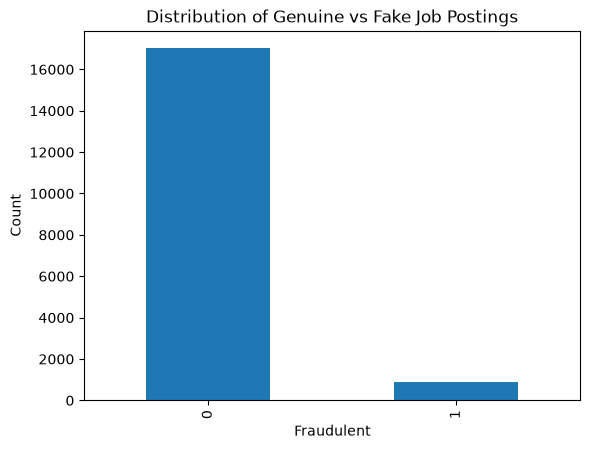

In [16]:
import matplotlib.pyplot as plt

df["fraudulent"].value_counts().plot(kind="bar")

plt.title("Distribution of Genuine vs Fake Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Count")

plt.show()

## Basic Statistical Summary

This section provides a summary of the numerical features in the dataset.

It helps identify the range, spread, and distribution of numeric variables.

In [17]:
# ==========================================================
# Statistical Summary
# ==========================================================

df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
# ==========================================================
# Statistical Summary (Including Categorical Features)
# ==========================================================

df.describe(include="all")

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
count,17880.000000,17880,17534,6333,2868,14572,17879,15184,10668,17880.000000,17880.000000,17880.000000,14409,10830,9775,12977,11425,17880.000000
unique,NaN,11231,3105,1337,874,1709,14801,11967,6204,NaN,NaN,NaN,5,7,13,131,37,NaN
top,NaN,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs abroad :),"Play with kids, get paid for it Love travel? Jobs in Asia$1,500+ USD monthly ($200 Cost of living)Housing provided (Private/Furnished)Airfare ReimbursedExcellent for student loans/credit cardsGabriel Adkins : #URL_ed9094c60184b8a4975333957f05be37e69d3cdb68decc9dd9a4242733cfd7f7##URL_75db76d58f7994c7db24e8998c2fc953ab9a20ea9ac948b217693963f78d2e6b#12 month contract : Apply today",University degree required. TEFL / TESOL / CELTA or teaching experience preferred but not necessaryCanada/US passport holders only,See job description,NaN,NaN,NaN,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,NaN
freq,NaN,311,718,551,142,726,379,410,726,NaN,NaN,NaN,11620,3809,5145,1734,1749,NaN
mean,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042897,0.795302,0.491723,NaN,NaN,NaN,NaN,NaN,0.048434
std,5161.655742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.202631,0.403492,0.499945,NaN,NaN,NaN,NaN,NaN,0.214688
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4470.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,13410.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000
